# Model Training & Evaluation

**Objective:** Train and evaluate baseline models (Logistic Regression, Random Forest).

**Models:**
1. Logistic Regression — Linear baseline, fast and interpretable
2. Random Forest — Non-linear baseline, captures complex patterns

**Key:** Both use `class_weight='balanced'` to handle severe class imbalance (0.17% fraud)

## 1. Setup & Load Processed Data

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Libraries imported")

Libraries imported


In [2]:
# Load processed data
processed_dir = Path('../data/processed')

X_train = joblib.load(processed_dir / 'X_train.pkl')
X_test = joblib.load(processed_dir / 'X_test.pkl')
y_train = joblib.load(processed_dir / 'y_train.pkl')
y_test = joblib.load(processed_dir / 'y_test.pkl')

print(f"Train: {X_train.shape[0]:,} samples x {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]:,} samples x {X_test.shape[1]} features")
print(f"\nFraud rate - Train: {y_train.mean():.4%}, Test: {y_test.mean():.4%}")

Train: 227,845 samples x 31 features
Test: 56,962 samples x 31 features

Fraud rate - Train: 0.1729%, Test: 0.1720%


## 2. Helper Functions for Evaluation

**Why these metrics?**
- **Recall**: Of all fraud cases, how many did we catch? (Most important!)
- **Precision**: Of predicted fraud, how many are actually fraud?
- **F1**: Balance between precision and recall
- **ROC-AUC**: Overall ability to distinguish classes

In [3]:
def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive evaluation of a model."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*60}")
    print(f"  {model_name} - Test Results")
    print(f"{'='*60}")
    
    # Classification report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud'],
                                  digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print("\n--- Confusion Matrix ---")
    print(f"                Predicted")
    print(f"               Legit  Fraud")
    print(f"Actual Legit   {tn:5d}  {fp:5d}")
    print(f"       Fraud   {fn:5d}  {tp:5d}")
    
    print(f"\n--- Key Metrics ---")
    print(f"  Fraud Recall (Catch Rate): {tp/(tp+fn):.4%}  <- Most Important!")
    print(f"  Fraud Precision:           {tp/(tp+fp):.4%}")
    print(f"  ROC-AUC:                   {roc_auc_score(y_test, y_proba):.4f}")
    
    return y_pred, y_proba, cm

def plot_roc_curve(models_data, save_path=None):
    """Plot ROC curves for multiple models."""
    plt.figure(figsize=(10, 8))
    
    for name, y_proba in models_data.items():
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve - Higher is Better', fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curve(models_data, save_path=None):
    """Plot Precision-Recall curves (better for imbalanced data)."""
    plt.figure(figsize=(10, 8))
    
    for name, y_proba in models_data.items():
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.4f})', linewidth=2)
    
    plt.xlabel('Recall (True Positive Rate)', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve - Higher is Better', fontsize=14)
    plt.legend(loc='lower left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Helper functions defined")

Helper functions defined


## 3. Model 1: Logistic Regression

**Key parameters:**
- `class_weight='balanced'` — Gives more weight to fraud cases
- `max_iter=1000` — More iterations for convergence
- `random_state=42` — Reproducible results

In [4]:
print("Training Logistic Regression...")

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

start = time.time()
logreg.fit(X_train, y_train)
train_time = time.time() - start

print(f"Training completed in {train_time:.2f} seconds")

Training Logistic Regression...


c:\Users\Dell\OneDrive\Desktop\Real-Time-Fraud-Detection-in-Digital-Payments\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Training completed in 4.26 seconds


In [5]:
# Evaluate Logistic Regression
y_pred_lr, y_proba_lr, cm_lr = evaluate_model(logreg, X_test, y_test, "Logistic Regression")


  Logistic Regression - Test Results

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate     0.9999    0.9747    0.9871     56864
       Fraud     0.0590    0.9184    0.1108        98

    accuracy                         0.9746     56962
   macro avg     0.5294    0.9466    0.5490     56962
weighted avg     0.9982    0.9746    0.9856     56962


--- Confusion Matrix ---
                Predicted
               Legit  Fraud
Actual Legit   55428   1436
       Fraud       8     90

--- Key Metrics ---
  Fraud Recall (Catch Rate): 91.8367%  <- Most Important!
  Fraud Precision:           5.8978%
  ROC-AUC:                   0.9726


## 4. Model 2: Random Forest

**Key parameters:**
- `n_estimators=100` — 100 decision trees
- `class_weight='balanced'` — Handle imbalance
- `max_depth=10` — Prevent overfitting
- `n_jobs=-1` — Use all CPU cores
- `random_state=42` — Reproducible

In [6]:
print("Training Random Forest...")
print("(This may take a minute or two)")

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start

print(f"Training completed in {train_time:.2f} seconds")

Training Random Forest...
(This may take a minute or two)
Training completed in 125.33 seconds


In [7]:
# Evaluate Random Forest
y_pred_rf, y_proba_rf, cm_rf = evaluate_model(rf, X_test, y_test, "Random Forest")


  Random Forest - Test Results

--- Classification Report ---
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9996    0.9997     56864
       Fraud     0.7885    0.8367    0.8119        98

    accuracy                         0.9993     56962
   macro avg     0.8941    0.9182    0.9058     56962
weighted avg     0.9994    0.9993    0.9993     56962


--- Confusion Matrix ---
                Predicted
               Legit  Fraud
Actual Legit   56842     22
       Fraud      16     82

--- Key Metrics ---
  Fraud Recall (Catch Rate): 83.6735%  <- Most Important!
  Fraud Precision:           78.8462%
  ROC-AUC:                   0.9794


## 5. Compare Models

In [8]:
# Calculate metrics for comparison
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Fraud Recall': [
        cm_lr[1,1] / (cm_lr[1,0] + cm_lr[1,1]),
        cm_rf[1,1] / (cm_rf[1,0] + cm_rf[1,1])
    ],
    'Fraud Precision': [
        cm_lr[1,1] / (cm_lr[0,1] + cm_lr[1,1]),
        cm_rf[1,1] / (cm_rf[0,1] + cm_rf[1,1])
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

print("\n" + "="*70)
print("              MODEL COMPARISON")
print("="*70)
print(models_comparison.to_string(index=False))
print("="*70)

winner = models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model']
print(f"\nWinner by ROC-AUC: {winner}")


              MODEL COMPARISON
              Model  Fraud Recall  Fraud Precision  ROC-AUC
Logistic Regression      0.918367         0.058978 0.972583
      Random Forest      0.836735         0.788462 0.979414

Winner by ROC-AUC: Random Forest


## 6. ROC Curves

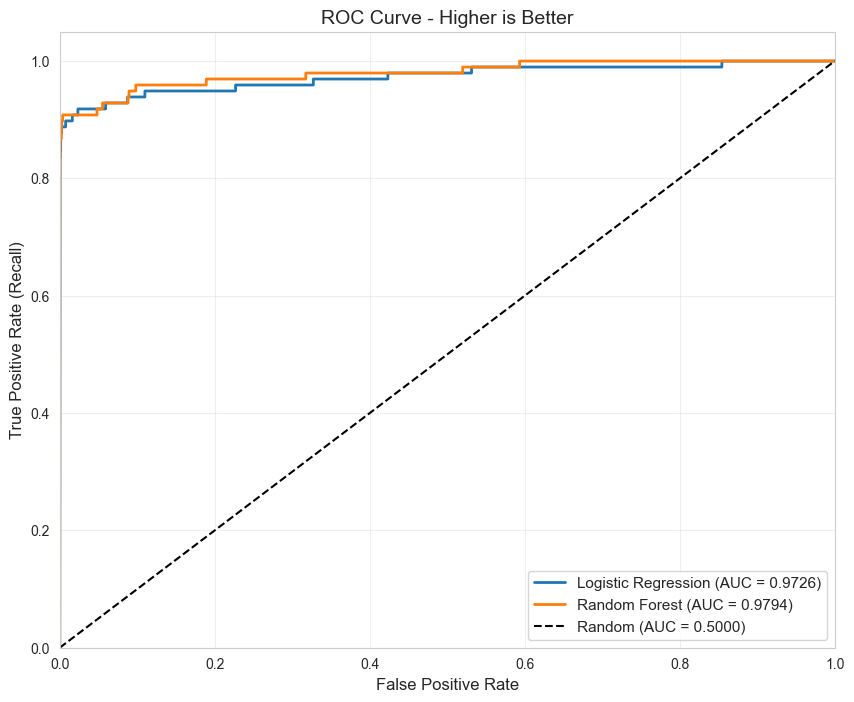

Saved: docs/images/baseline_roc_curves.png


In [9]:
plot_roc_curve(
    {'Logistic Regression': y_proba_lr, 'Random Forest': y_proba_rf},
    save_path='../docs/images/baseline_roc_curves.png'
)
print("Saved: docs/images/baseline_roc_curves.png")

## 7. Precision-Recall Curves

**Note:** PR curve is more informative than ROC for imbalanced datasets.

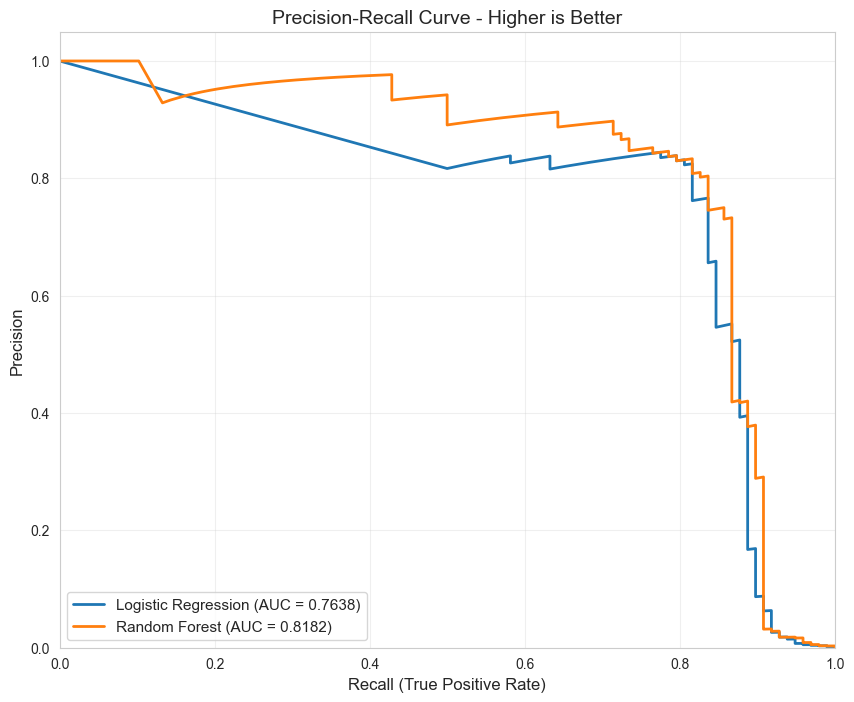

Saved: docs/images/baseline_pr_curves.png


In [10]:
plot_precision_recall_curve(
    {'Logistic Regression': y_proba_lr, 'Random Forest': y_proba_rf},
    save_path='../docs/images/baseline_pr_curves.png'
)
print("Saved: docs/images/baseline_pr_curves.png")

## 8. Feature Importance (Random Forest)

Random Forest can tell us which features are most predictive.

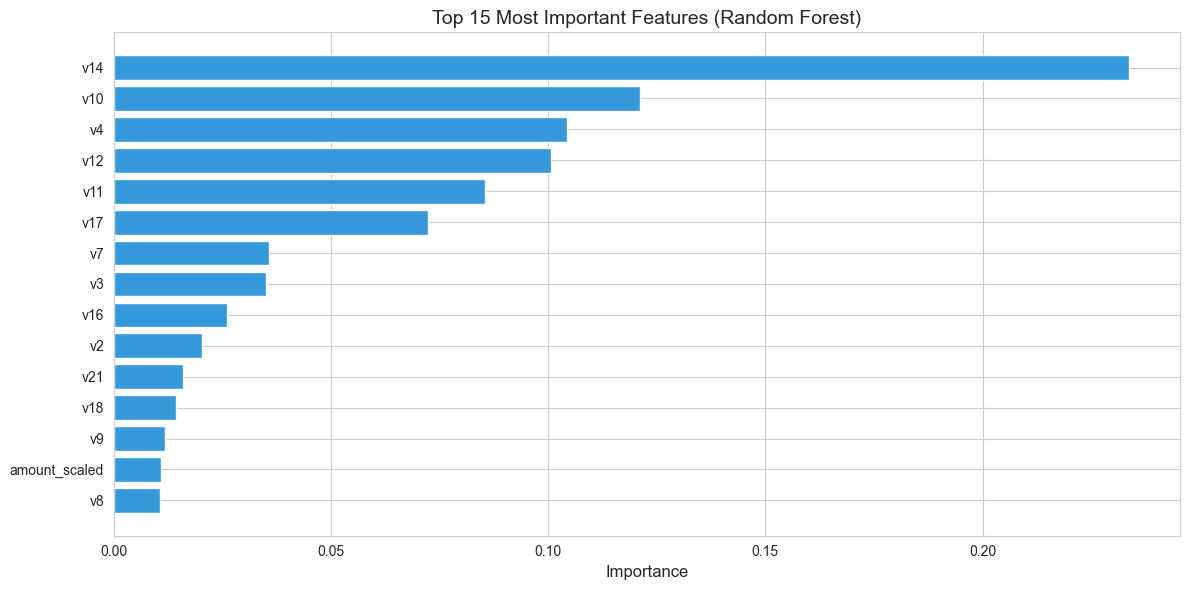


--- Top 15 Features ---
      feature  importance
          v14    0.233790
          v10    0.121052
           v4    0.104291
          v12    0.100524
          v11    0.085489
          v17    0.072219
           v7    0.035765
           v3    0.034918
          v16    0.026004
           v2    0.020232
          v21    0.015892
          v18    0.014350
           v9    0.011646
amount_scaled    0.010870
           v8    0.010524

Saved: docs/images/feature_importance.png


In [11]:
# Get feature importance
importance = rf.feature_importances_
feature_names = X_train.columns.tolist()

# Create dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

# Plot top 15
plt.figure(figsize=(12, 6))
top15 = importance_df.head(15)
plt.barh(range(len(top15)), top15['importance'].values[::-1], color='#3498db')
plt.yticks(range(len(top15)), top15['feature'].values[::-1])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/images/feature_importance.png', dpi=150)
plt.show()

print("\n--- Top 15 Features ---")
print(importance_df.head(15).to_string(index=False))
print("\nSaved: docs/images/feature_importance.png")

## 9. Save Models

In [12]:
# Create models directory
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save models
joblib.dump(logreg, models_dir / 'logreg_baseline.pkl')
joblib.dump(rf, models_dir / 'rf_baseline.pkl')

# Save predictions for comparison
predictions = {
    'y_test': y_test,
    'logreg_pred': y_pred_lr,
    'logreg_proba': y_proba_lr,
    'rf_pred': y_pred_rf,
    'rf_proba': y_proba_rf
}
joblib.dump(predictions, models_dir / 'baseline_predictions.pkl')

print("\n=== Models Saved ===")
print(f"  {models_dir / 'logreg_baseline.pkl'}")
print(f"  {models_dir / 'rf_baseline.pkl'}")
print(f"  {models_dir / 'baseline_predictions.pkl'}")


=== Models Saved ===
  ..\models\logreg_baseline.pkl
  ..\models\rf_baseline.pkl
  ..\models\baseline_predictions.pkl


## 10. Summary Report

In [13]:
print("\n" + "="*70)
print("              BASELINE MODELS - SUMMARY")
print("="*70)

print("\nModels Trained:")
print("  1. Logistic Regression (linear baseline)")
print("  2. Random Forest (non-linear baseline)")

print("\nKey Configuration:")
print("  - class_weight='balanced' (both models)")
print("  - random_state=42 (reproducible)")

print("\nEvaluation Metrics Computed:")
print("  - Fraud Recall (primary metric)")
print("  - Fraud Precision")
print("  - ROC-AUC")
print("  - Precision-Recall AUC")

print("\nFiles Created:")
print(f"  Models:        {models_dir}/")
print(f"  Charts:        docs/images/")

print("\nNext Steps:")
print("  - Day 5: XGBoost + Optuna hyperparameter tuning")
print("  - Day 6: Address class imbalance with advanced techniques")
print("  - Day 7: Final model selection and model card")

print("="*70)


              BASELINE MODELS - SUMMARY

Models Trained:
  1. Logistic Regression (linear baseline)
  2. Random Forest (non-linear baseline)

Key Configuration:
  - class_weight='balanced' (both models)
  - random_state=42 (reproducible)

Evaluation Metrics Computed:
  - Fraud Recall (primary metric)
  - Fraud Precision
  - ROC-AUC
  - Precision-Recall AUC

Files Created:
  Models:        ..\models/
  Charts:        docs/images/

Next Steps:
  - Day 5: XGBoost + Optuna hyperparameter tuning
  - Day 6: Address class imbalance with advanced techniques
  - Day 7: Final model selection and model card
